In [14]:
import yfinance as yf
import pandas as pd
import data as pdr
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt

In [5]:
enddate = dt.datetime.now()
startdate = enddate - dt.timedelta(days=365*5)
enddate, startdate

(datetime.datetime(2026, 2, 15, 20, 15, 47, 946952),
 datetime.datetime(2021, 2, 16, 20, 15, 47, 946952))

In [6]:
stocks = ['MSFT', 'SPY', 'QQQ']

In [7]:
df = yf.download(stocks, start=startdate, end=enddate)

[*********************100%***********************]  3 of 3 completed


In [8]:
df.head()

Price            Close                                High              \
Ticker            MSFT         QQQ         SPY        MSFT         QQQ   
Date                                                                     
2021-02-17  234.859299  324.054962  366.286743  234.965092  325.733813   
2021-02-18  234.464966  322.638245  364.727844  234.599610  323.996838   
2021-02-19  231.752808  321.231079  364.083740  234.532263  324.113252   
2021-02-22  225.539932  312.904785  361.283325  228.829115  318.106265   
2021-02-23  224.347382  311.973206  361.722046  225.847709  313.642343   

Price                          Low                                Open  \
Ticker             SPY        MSFT         QQQ         SPY        MSFT   
Date                                                                     
2021-02-17  366.538771  231.724000  320.406174  363.430280  232.089469   
2021-02-18  365.474614  231.647046  318.649770  361.946075  232.551093   
2021-02-19  366.277415  230.993017  320.212142  363.635661  234.426470   
2021-02-22  363.701025  223.510640  312.701004  361.012609  228.338628   
2021-02-23  363.075598  219.981029  301.803109  354.907681  221.519835   

Price                                 Volume                       
Ticker             QQQ         SPY      MSFT       QQQ        SPY  
Date                                                               
2021-02-17  322.638146  364.447794  21653500  31360300   52290600  
2021-02-18  320.464495  363.673012  16925600  32236200   59712800  
2021-02-19  323.987091  365.988040  25262600  39157700   83241000  
2021-02-22  316.844720  361.311328  36446900  47256900   67414200  
2021-02-23  307.625677  359.070977  30228700  97241900  107284100

In [10]:
adj_close = df['Close']
adj_close.head()

Ticker,MSFT,QQQ,SPY
Date,,,
2021-02-17,234.859299,324.054962,366.286743
2021-02-18,234.464966,322.638245,364.727844
2021-02-19,231.752808,321.231079,364.083740
2021-02-22,225.539932,312.904785,361.283325
2021-02-23,224.347382,311.973206,361.722046


In [11]:
log_returns = np.log(adj_close / adj_close.shift(1))
log_returns.head()

Ticker,MSFT,QQQ,SPY
Date,,,
2021-02-17,NaN,NaN,NaN
2021-02-18,-0.001680,-0.004381,-0.004265
2021-02-19,-0.011635,-0.004371,-0.001768
2021-02-22,-0.027174,-0.026262,-0.007721
2021-02-23,-0.005302,-0.002982,0.001214


In [12]:
cumulative_log_returns = log_returns.cumsum()
cumulative_log_returns.head()

Ticker,MSFT,QQQ,SPY
Date,,,
2021-02-17,NaN,NaN,NaN
2021-02-18,-0.001680,-0.004381,-0.004265
2021-02-19,-0.013315,-0.008752,-0.006033
2021-02-22,-0.040489,-0.035014,-0.013754
2021-02-23,-0.045791,-0.037996,-0.012540


<Axes: title={'center': 'Cumulative returns'}, xlabel='Date'>

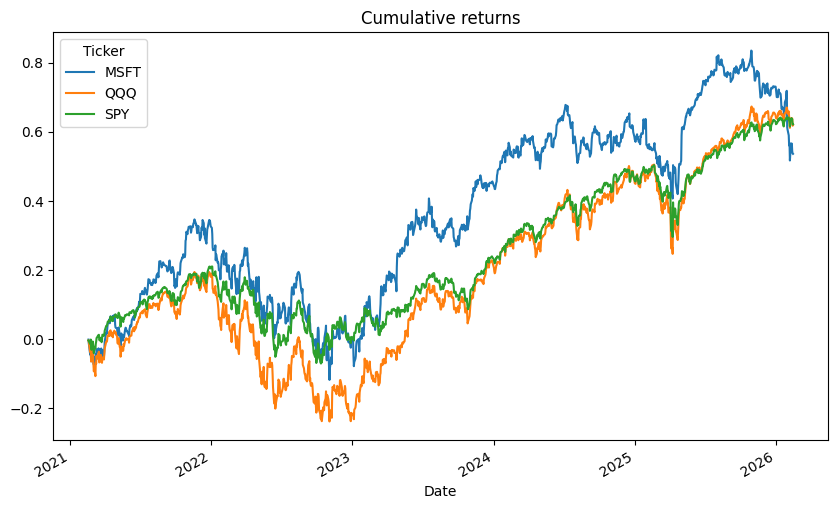

In [16]:
cumulative_log_returns.plot(title = 'Cumulative returns', figsize=(10, 6))